In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import math
import matplotlib.cm as cm
import matplotlib as mpl
from Testing.RTLO import *

In [2]:
class DataCloud:
	N=0
	def __init__(self,x,ID,nS=1):
		self.ID = ID
		self.track = [ID]
		self.merged = False
		self.merge = None
		self.n=1
		self.mean=x
		self.meant=np.array(x).dot(np.array(x))
		self.variance=0
		self.pertinency=1
		self.tipicality=1e-12
		self.nS = nS
		self.x = []
		self.t = []
		self.R = 0
		self.xI = None
		self.xF = None
		self.Rmax = 0
		self.specificity = 0
		self.coverage = 0
		self.cardinality = 1
		self.v = 0
		self.Dmax = -np.inf
		
	def addDataClaud(self,x):
		self.n=2
		self.mean=(self.mean+x)/2
		self.meant=((self.meant)/2) + (x.dot(x))/2
		self.variance=self.meant-self.mean.dot(self.mean)

	def updateDataCloud(self,n,mean,meant,variance,tipicality):
		self.n=n
		self.mean=mean
		self.meant=meant
		self.variance=variance
		self.tipicality=tipicality
		self.cardinality=self.cardinality + 1
		
class AutoCloud:
	def __init__(self,m,nS=1):
		
		self.nS = nS
	
		self.g = 1
		self.gCreated = 1
		self.c= np.array([DataCloud(np.array([0]),self.gCreated,self.nS)],dtype=DataCloud)
		self.alfa= np.array([0.0],dtype=float)
		self.intersection = np.zeros((1,1),dtype=int)
		self.listIntersection = np.zeros((1),dtype=int)
		self.matrixIntersection = np.zeros((1,1),dtype=int)
		self.relevanceList = np.zeros((1),dtype=int)
		self.classIndex = []
		self.k=1
		self.m = m
		self.cloud_activation = []
		self.cloud_activation2 = []
		self.cloud_activation3 = []
		self.aux = np.array([])
		self.DSIs = [np.array([]) for i in range(nS)]
		self.OffineGrnls = None

		self.eolX = 0
		self.HI = np.array([])
		self.DSI = np.array([])
		self.eolDSI = 0
		self.HIp = np.array([])
		self.cycleP=np.array([])

		self.rulL = np.array([])
		self.rulP = np.array([])
		self.rulU = np.array([])
		self.rulR2 = np.array([])

		self.xR = 0
		self.xF = 0
		self.Dmax = 0
	
	def mergeClouds(self):
		i=0
		while(i<len(self.listIntersection)-1):
			merge=False
			j=i+1
			while(j<len(self.listIntersection)):
				#print("i",i,"j",j,"l",np.size(AutoCloud.listIntersection),"m",np.size(AutoCloud.matrixIntersection),"c",np.size(AutoCloud.c))
				if(self.listIntersection[i] == 1 and self.listIntersection[j] == 1):
					self.matrixIntersection[i,j] = self.matrixIntersection[i,j] + 1;
				#print('erro merge')
				idI = self.c[i].ID
				idJ = self.c[j].ID
				meanI = self.c[i].mean
				meanJ = self.c[j].mean
				meantI = self.c[i].meant
				meantJ = self.c[j].meant
				nI = self.c[i].n
				nJ = self.c[j].n
				tipicalityI = self.c[i].tipicality
				tipicalityJ = self.c[j].tipicality
				trackI = self.c[i].track
				trackJ = self.c[j].track
				varianceI = self.c[i].variance
				varianceJ = self.c[j].variance
				
				#print(self.c[i].ID,np.max(self.c[i].R),self.k)
				#print(self.c[j].ID,np.max(self.c[j].R),self.k)
				#rI = np.max(self.c[i].R)
				#rJ = np.max(self.c[j].R)

				nIntersc = self.matrixIntersection[i,j]

				if (nIntersc > (nI - nIntersc) or nIntersc > (nJ - nIntersc)):
	
					rI = np.max(self.c[i].R)
					rJ = np.max(self.c[j].R)
					
					#print(self.c[i].x + self.c[j].x)
					
					if rI >= rJ: radius = rI
					else: radius = rJ
					merge = True
					self.gCreated = self.gCreated + 1
					#update values
					n = nI + nJ - nIntersc
					mean = ((nI * meanI) + (nJ * meanJ))/(nI + nJ)
					#radius = ((nI * rI) + (nJ * rJ))/(nI + nJ)
					meant = ((nI * meantI) + (nJ * meantJ))/(nI + nJ)
					variance = ((nI - 1) * varianceI + (nJ - 1) * varianceJ)/(nI + nJ - 2)
					tipicality = ((nI*tipicalityI)+(nJ*tipicalityJ))/(nI + nJ)
				

					newCloud = DataCloud(np.array([0]),self.gCreated,self.nS)
					for id in trackI:
						newCloud.track.append(id)
					for id in trackJ:
						newCloud.track.append(id)
						
					newCloud.updateDataCloud(n,mean,meant,variance,tipicality)
					newCloud.R = radius
					
					x = self.c[i].x + self.c[j].x
					t = self.c[i].t + self.c[j].t
					
					mat = np.array(list(zip(t,x)), dtype=object)
					col = mat[:, 0].astype(int) 
					_, index = np.unique(col, return_index=True)
					result = mat[np.sort(index)]
					t = result[:, 0].tolist()
					x = result[:, 1].tolist()
					newCloud.x = x
					newCloud.t = t
					
					newCloud.merge = f'G{self.gCreated}: G{idI}+G{idJ}'

					self.aux = np.append(self.aux,newCloud.ID)

					#atualizando lista de interseção
					self.listIntersection = np.concatenate((self.listIntersection[0 : i], np.array([1]), self.listIntersection[i + 1 : j],self.listIntersection[j + 1 : np.size(self.listIntersection)]),axis=None)
					#atualizando lista de data clouds 
					self.c = np.concatenate((self.c[0 : i ], np.array([newCloud]), self.c[i + 1 : j],self.c[j + 1 : np.size(self.c)]),axis=None)
					
					#update  intersection matrix
					M0 = self.matrixIntersection
					#Remover linhas 
					M1=np.concatenate((M0[0 : i , :],np.zeros((1,len(M0))),M0[i + 1 : j, :],M0[j + 1 : len(M0), :]))
					#remover colunas
					M1=np.concatenate((M1[:, 0 : i ],np.zeros((len(M1),1)),M1[:, i+1 : j],M1[:, j+1 : len(M0)]),axis=1)
					#calculando nova coluna
					col = (M0[:, i] + M0[:, j])*(M0[: , i]*M0[:, j] != 0)
					col = np.concatenate((col[0 : j], col[j + 1 : np.size(col)]))
					#calculando nova linha
					lin = (M0[i, :]+M0[j, :])*(M0[i, :]*M0[j, :] != 0)
					lin = np.concatenate((lin[ 0 : j], lin[j + 1 : np.size(lin)]))
					#atualizando coluna
					M1[:,i]=col
					#atualizando linha
					M1[i,:]=lin
					M1[i, i + 1 : j] = M0[i, i + 1 : j] + M0[i + 1 : j, j].T;   
					self.matrixIntersection = M1
				j += 1
			if(merge):
				i = 0
			else:
				i += 1

	def run(self,X):
		for i,x in enumerate(X):
			self.DSIs[i] = np.append(self.DSIs[i], X[i])
		self.aux = np.array([])
		self.aux2 = np.array([])
		if self.k == 1: self.xR = X
		self.listIntersection = np.zeros((np.size(self.c)),dtype=int)
		if self.k==1:
			self.c[0] = DataCloud(X,self.gCreated,self.nS)
			self.c[0].x.append(X)
			self.c[0].t.append(self.k)
			self.c[0].xI = X
			self.c[0].R = 0
			self.aux = np.append(self.aux,1)
			self.aux2 = np.append(self.aux,self.c[0].track)

		elif self.k==2:
			self.c[0].addDataClaud(X)
			self.c[0].x.append(X)
			self.c[0].t.append(self.k)
			v = self.c[0].variance
			n1 = self.c[0].n
			n2 = self.c[0].n
			R = math.sqrt((((self.m**2)+1)*n2*v/n1)-v)
			self.c[0].R = R
			self.c[0].cardinality = self.c[0].cardinality+1
			self.aux = np.append(self.aux,1)
			self.aux2 = np.append(self.aux,self.c[0].track)

		elif self.k>=3:
			i=0
			createCloud = True
			self.alfa = np.zeros((np.size(self.c)),dtype=float)
			for cloud in self.c:
				n= cloud.n +1
				mean = ((n-1)/n)*cloud.mean + (1/n)*X
				meant = ((n-1)/n) * cloud.meant + (X.dot(X))/n
				variance=meant-mean.dot(mean)
				eccentricity = (1/n)+((mean-X).T.dot(mean-X))/(n*variance)
				typicality = 1 - (eccentricity-(1e-12))
				norm_eccentricity = eccentricity/2
				norm_typicality = typicality/(self.k-2)
				cloud.eccAn = eccentricity
				n1 = n
				n2 = n
				R = math.sqrt((((self.m**2)+1)*n2*variance/n1)-variance)
				if(norm_eccentricity<=(self.m**2 +1)/(2*n)):
					createCloud= False
					cloud.updateDataCloud(n,mean,meant,variance,typicality)
					self.alfa[i] = norm_typicality
					self.listIntersection.itemset(i,1)
					#aux = np.append(aux,cloud.ID)
					cloud.x.append(X)
					cloud.t.append(self.k)
					cloud.xF = X
					cloud.R = R
					self.aux = np.append(self.aux,cloud.ID)
					self.aux2 = np.append(self.aux2,cloud.track)
				else:
					self.alfa[i] = 0
					self.listIntersection.itemset(i,0)
				i+=1

			if(createCloud):
				self.gCreated = self.gCreated + 1
				self.c = np.append(self.c,DataCloud(X,self.gCreated,self.nS))
				self.listIntersection = np.insert(self.listIntersection,i,1)
				self.matrixIntersection = np.pad(self.matrixIntersection, ((0,1),(0,1)), 'constant', constant_values=(0)) 
				self.c[-1].x.append(X)
				self.c[-1].t.append(self.k)
				self.c[-1].xI = X
				self.c[-1].R = 0
				self.aux = np.append(self.aux,self.c[-1].ID)
				self.aux2 = np.append(self.aux2,self.c[-1].track)

			self.mergeClouds()
		
		
		self.cloud_activation.append(self.aux)
		self.cloud_activation2.append(self.aux)
		self.cloud_activation3.append(self.aux2)
		#self.rulR = np.append(self.rulR, )
		self.k=self.k+1


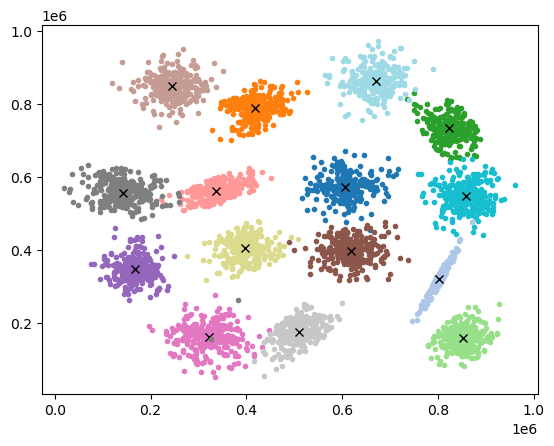

In [24]:
data = pd.read_csv('s1.csv',sep=';',header=None)
dados = np.array([data.iloc[:,0],data.iloc[:,1]])
xS = dados.T

teda=AutoCloud(m=2, nS=len(xS[0])) 
for x in xS:
    teda.run(X=x)

cmap = mpl.colormaps.get_cmap('tab20').resampled(len(teda.c))
colors = [cmap(i) for i in range(len(teda.c))]

for i,cloud in enumerate(teda.c):
    sig = np.array(cloud.x).T
    plt.plot(sig[0],sig[1],marker='.',linestyle='',color=colors[i])
    plt.plot(cloud.mean[0],cloud.mean[1],marker='x',linestyle='',color='black')